# 05 — Evaluation

Load the tuned Ridge model from `notebooks/_artifacts/`, score it on the held-out test set, and inspect:

- Test MSE / RMSE / R²
- Predicted vs. actual scatter
- Residual distribution
- Residuals vs. predictions (heteroscedasticity check)

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SCRATCH = REPO_ROOT / "notebooks" / "_artifacts"

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from joblib import load
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

model = load(SCRATCH / "ridge.joblib")
X_test_scaled = np.load(SCRATCH / "X_test_scaled.npy")
y_test = np.load(SCRATCH / "y_test.npy")

preds = model.predict(X_test_scaled)
residuals = y_test - preds

mse = mean_squared_error(y_test, preds)
rmse = float(np.sqrt(mse))
r2 = r2_score(y_test, preds)

print(f"test MSE:  {mse:>15,.0f}")
print(f"test RMSE: {rmse:>15,.0f}")
print(f"test R^2:  {r2:>15.4f}")

test MSE:    4,927,999,084
test RMSE:          70,200
test R^2:           0.6699


## Predicted vs. actual

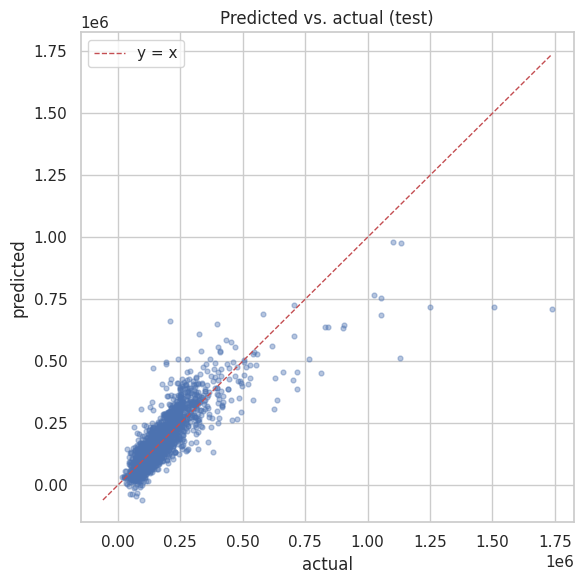

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, alpha=0.4, s=12)
lo, hi = float(min(y_test.min(), preds.min())), float(max(y_test.max(), preds.max()))
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
ax.set_xlabel("actual")
ax.set_ylabel("predicted")
ax.set_title("Predicted vs. actual (test)")
ax.legend()
plt.tight_layout(); plt.show()

## Residual distribution

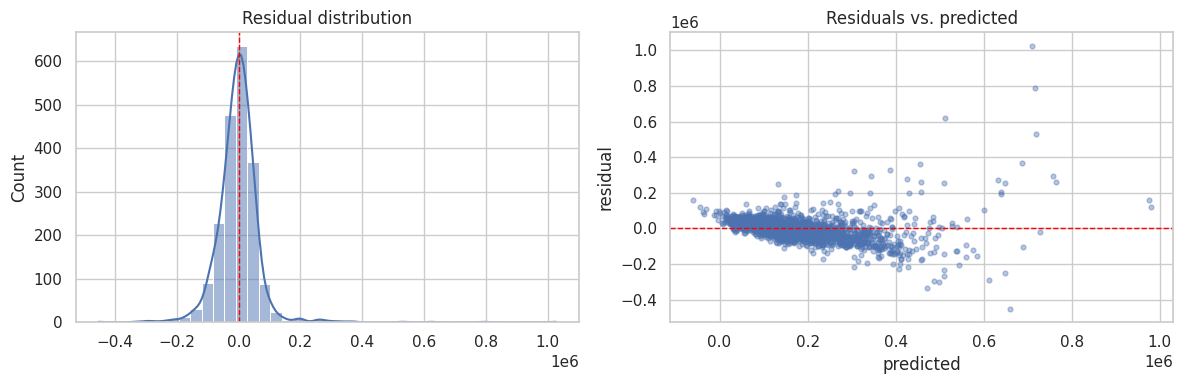

residual mean:         -2,234
residual median:         -633
residual std:          70,164


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, bins=40, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residual distribution")

axes[1].scatter(preds, residuals, alpha=0.4, s=12)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs. predicted")
plt.tight_layout(); plt.show()

print(f"residual mean:   {residuals.mean():>12,.0f}")
print(f"residual median: {np.median(residuals):>12,.0f}")
print(f"residual std:    {residuals.std():>12,.0f}")